# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

Each observation represents one completed, non-diverted domestic flight in the sample.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |

See `data/README.md` for source, sampling, and preparation details.


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [36]:
# Write your code here.
import pandas as pd

flights = pd.read_csv('data/bts_flights_may_2026_sample.csv')

Display the first five rows of the DataFrame.


In [37]:
# Write your code here.
flights.head(5)


,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [38]:
# Write your code here.
flights.tail(5)


,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [39]:
# Write your code here.
flights.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   airline                5000 non-null   str  
 1   origin_city            5000 non-null   str  
 2   destination_city       5000 non-null   str  
 3   distance_miles         5000 non-null   int64
 4   arrival_delay_minutes  5000 non-null   int64
dtypes: int64(2), str(3)
memory usage: 399.5 KB


**How many observations are in the DataFrame?**

Your answer: 5000


Count the missing values in every feature.


In [40]:
# Write your code here.
flights.isnull().sum()


airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type and feature type of each feature.**

| Feature | Pandas data type | Feature type |
| --- | --- | --- |
| `airline` | str | Categorical |
| `origin_city` | str | Categorical |
| `destination_city` | str | Categorical |
| `distance_miles` | int64 | Quantitative |
| `arrival_delay_minutes` | int64 | Quantitative |


## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [41]:
# Write your code here.
destination_counts = flights['destination_city'].value_counts()

destination_counts

destination_city
Chicago, IL                      296
Atlanta, GA                      222
Dallas/Fort Worth, TX            210
Denver, CO                       209
Washington, DC                   165
                                ... 
Watertown, SD                      1
Cedar City, UT                     1
Sun Valley/Hailey/Ketchum, ID      1
Carlsbad, CA                       1
Redding, CA                        1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


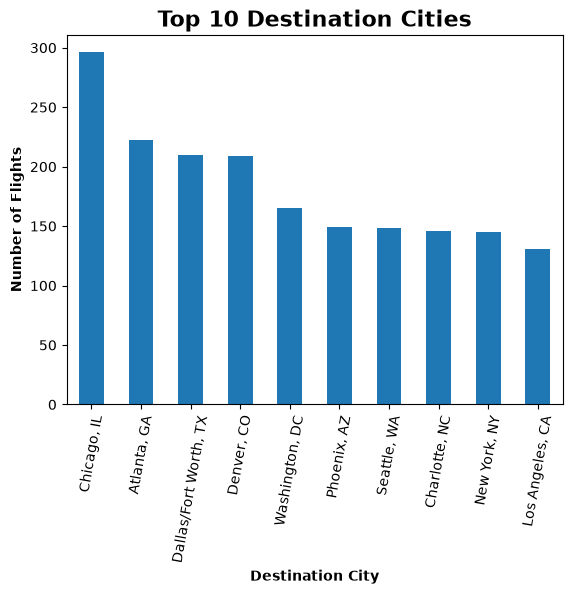

In [42]:
# Write your code here.
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind='bar')
plt.xlabel('Destination City', weight='bold')
plt.ylabel('Number of Flights', weight='bold')
plt.title('Top 10 Destination Cities', fontsize=16, fontweight='bold')
plt.xticks(rotation=80)
plt.show()


**Which destination city is most common in the sample?**

Your answer: Chicago, IL


## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


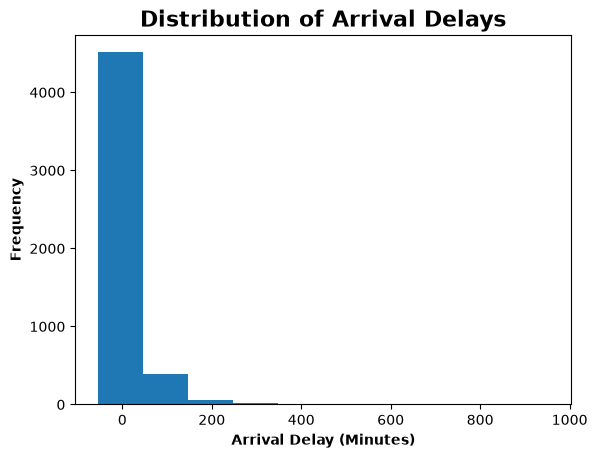

In [43]:
# Write your code here.
flights['arrival_delay_minutes'].plot(kind='hist')
plt.xlabel('Arrival Delay (Minutes)', weight='bold')
plt.ylabel('Frequency', weight='bold')
plt.title('Distribution of Arrival Delays', fontsize=16, fontweight='bold')
plt.show()



**Approximately what arrival-delay value appears most common?**

Your answer: 0


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer:
0 to 300 minutes

**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer: Right skewed


Display a numerical summary of `arrival_delay_minutes`.


In [44]:
# Write your code here.
flights['arrival_delay_minutes'].describe()



count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [45]:
# Write your code here.
flights['arrival_delay_minutes'].mode()


0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: Off by -8 minutes


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer: Off by 700 minutes for the max and 55 for the min


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: greater by over 12 minutes


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: Since the histogram is right-skewed, the mean is greater thanks to the outliers pulling it right of the median


## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


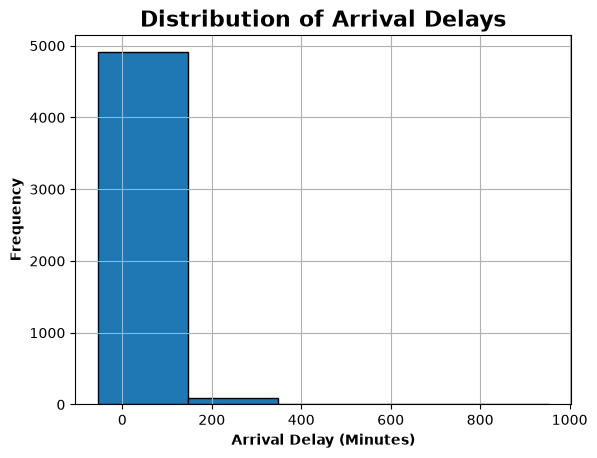

In [46]:
# Write your code here.
flights['arrival_delay_minutes'].hist(bins=5, edgecolor='black')
plt.xlabel('Arrival Delay (Minutes)', weight='bold')
plt.ylabel('Frequency', weight='bold')
plt.title('Distribution of Arrival Delays', fontsize=16, fontweight='bold')
plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


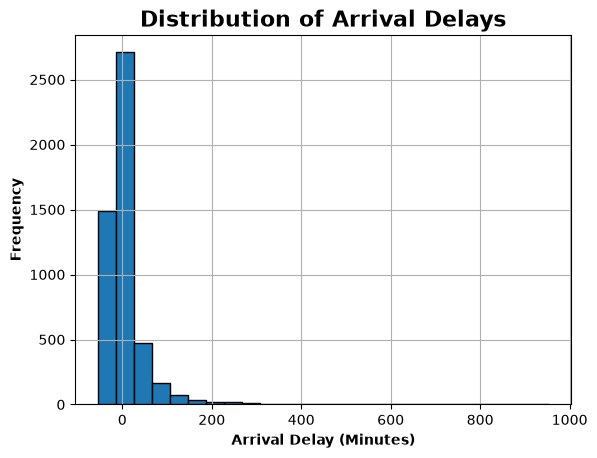

In [47]:
# Write your code here.
flights['arrival_delay_minutes'].hist(bins=25, edgecolor='black')
plt.xlabel('Arrival Delay (Minutes)', weight='bold')
plt.ylabel('Frequency', weight='bold')
plt.title('Distribution of Arrival Delays', fontsize=16, fontweight='bold')
plt.show()


**What changed when the number of bins was reduced to 5?**

Your answer: How clearly the delays were represented. The size of the bins hides the nuance of the delay times below 200 minutes.


**What changed when the number of bins was increased to 25?**

Your answer: ~1500 flights were early. The much narrower bins made that very obvious.


**Which bin setting communicates the distribution most clearly?**

Your answer: Easily the 25 bin. Its much more detailed representation of the actual distribution while the smaller number of bins lumped too many observations together masking their true shape


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


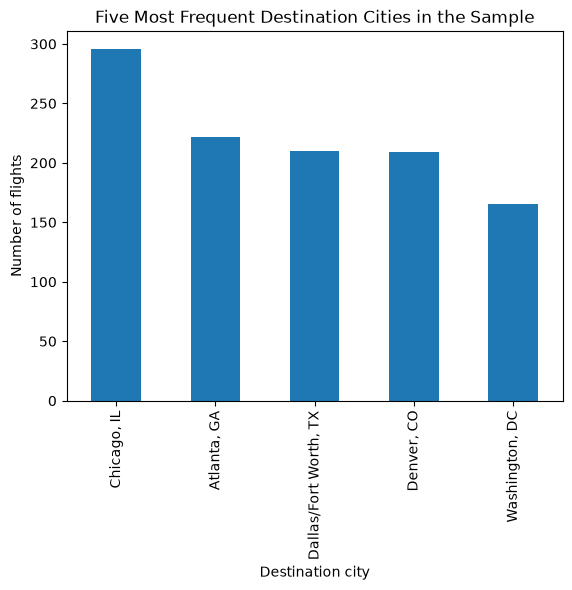

In [48]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


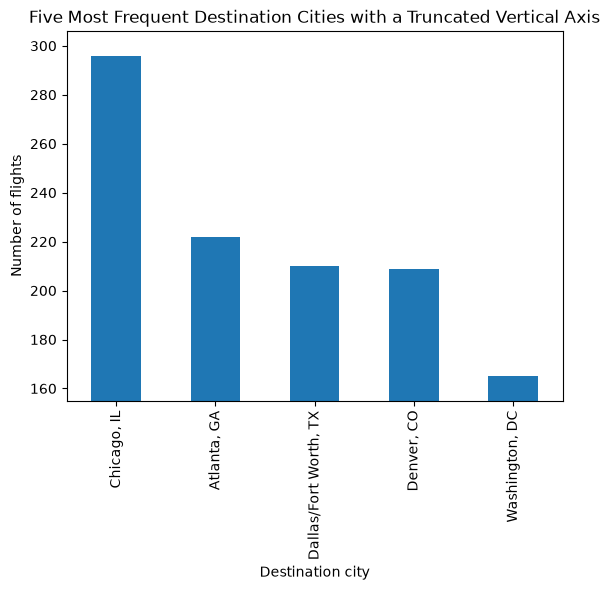

In [49]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: The truncated axis gives the impression that DC has substantially fewer flights. By starting at 155 instead of zero, Denver looks like it has over 5 times as many flights which can mislead anyone not closely looking at the axis values


**Which chart communicates the counts more honestly?**

Your answer: The first graph is vastly more honest. The visual range shows the full scale of the flights at each airport.


## Is this sample representative?

Review `data/README.md` before answering these questions.


**What time period is represented by the source data?**

Your answer: One month. May 2026


**Which flights were eligible to be included in the sample?**

Your answer: Completed, non-diverted flights with recorded values for all 5 selected features


**Which flights and records were excluded before the sample was selected?**

Your answer: Canceled, diverted and records missing any selected feature


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer: No the original BTS data could have missing values. Since those were filtered out of the sample, the sample can't represent the original data


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: The sample excluded both of those so it can't be used to make conclusions on those types of flights


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. These questions use features that you did not visualize earlier in the lab.


**Which chart would you use to show the frequency of each airline?**

Your answer: Bar chart


**Which chart would you use to show what share of sampled flights departed from each origin city?**

Your answer: I'm not sure I'd pick any of these considering how many cities would need to be represented. Maybe if the grouping was per state or like the first graph a 10 ten with the cavaet that the smaller cities were lumped into an others category? Then I suppose I could use a bar chart.


**Which chart would you use to show the distribution of flight distances?**

Your answer: Histogram


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used: Gemini
- What I asked it to help with: The sampled flights from origin cities question. I felt it was a trick question
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why: I used it as a sounding board to collect my thoughts.

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response:


## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The AI-use reflection is complete and honest.
